# Dataset EDA: ClArTTS & dataset_new_omani

Descriptive statistics, exploratory data analysis, and visualizations for both TTS datasets used in this project.

- **ClArTTS** – Modern Standard Arabic (MSA) TTS dataset (Clearbox AI), stored as Parquet
- **dataset_new_omani** – Omani Arabic dialect single-speaker TTS dataset, stored as FLAC + XLSX transcriptions

In [1]:
import os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torchaudio
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = os.path.dirname(os.path.abspath('__file__'))

CLARTTS_TRAIN  = os.path.join(BASE, 'clartts', 'clartts_train.parquet')
CLARTTS_VAL    = os.path.join(BASE, 'clartts', 'clartts_val.parquet')
CLARTTS_TEST   = os.path.join(BASE, 'clartts', 'clartts_test.parquet')

OMANI_ROOT     = os.path.join(BASE, 'dataset_new_omani')
OMANI_XLSX     = os.path.join(OMANI_ROOT, 'transcriptions.xlsx')
OMANI_AUDIO    = os.path.join(OMANI_ROOT, 'clean_flac')

print('Base dir :', BASE)
print('ClArTTS train:', os.path.exists(CLARTTS_TRAIN))
print('Omani XLSX   :', os.path.exists(OMANI_XLSX))

Base dir : c:\Users\user\Documents\Semester 11\Course Project 2\tacotron2-wavernn
ClArTTS train: True
Omani XLSX   : True


## 1. Load Datasets

In [2]:
# ── ClArTTS ────────────────────────────────────────────────────────────────
print('Loading ClArTTS parquet files...')
df_train = pd.read_parquet(CLARTTS_TRAIN, columns=['text', 'file', 'duration', 'sampling_rate'])
df_val   = pd.read_parquet(CLARTTS_VAL,   columns=['text', 'file', 'duration', 'sampling_rate'])
df_test  = pd.read_parquet(CLARTTS_TEST,  columns=['text', 'file', 'duration', 'sampling_rate'])

df_train['split'] = 'train'
df_val['split']   = 'val'
df_test['split']  = 'test'

clartts = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'ClArTTS total samples: {len(clartts):,}')
print(clartts.dtypes)
clartts.head(3)

Loading ClArTTS parquet files...
ClArTTS total samples: 9,705
text              object
file              object
duration         float64
sampling_rate      int64
split             object
dtype: object


,text,file,duration,sampling_rate,split
0,مَعَانٍ كَامِنَةٌ تُعْرَفُ بِسِمَاتٍ دَالَّةٍ,ch_14_arabic_tts_dataset_552.wav,3.42,40100,train
1,أَدَبُ الرِّيَاضَةِ وَالِاسْتِصْلَاحِ وَأَمَّا...,ch_14_arabic_tts_dataset_106.wav,5.00,40100,train
2,فَقَالَ بَعْضُ الشُّعَرَاءِ وَلَمْ ذَاكَ الْبَ...,ch_11_arabic_tts_dataset_20.wav,3.60,40100,train


In [3]:
# ── dataset_new_omani ──────────────────────────────────────────────────────
print('Loading Omani dataset...')
omani = pd.read_excel(OMANI_XLSX)
omani.columns = omani.columns.str.strip()
omani = omani[['File Name', 'Text']].dropna().copy()
omani.rename(columns={'File Name': 'file_name', 'Text': 'text'}, inplace=True)
omani['file_path'] = omani['file_name'].apply(lambda n: os.path.join(OMANI_AUDIO, n))

print(f'Omani total samples: {len(omani):,}')
print(omani.dtypes)
omani.head(3)

Loading Omani dataset...
Omani total samples: 4,478
file_name    object
text         object
file_path    object
dtype: object


,file_name,text,file_path
0,111_c13abfaf_0000.flac,العنف بين النزاعات والتوجهات الإسلامية هو,c:\Users\user\Documents\Semester 11\Course Pro...
1,111_c13abfaf_0001.flac,اختلافهم في الدرجة وعيس النوع في الأفكار الأحدية,c:\Users\user\Documents\Semester 11\Course Pro...
2,111_c13abfaf_0002.flac,بما أنني اعتقل بأنني على مذهب,c:\Users\user\Documents\Semester 11\Course Pro...


In [4]:
# Get audio durations for Omani dataset via torchaudio metadata (no full decode)
OMANI_SR = 22050  # target sample rate

def get_duration(path):
    try:
        info = torchaudio.info(path)
        return info.num_frames / info.sample_rate
    except Exception:
        return np.nan

print('Reading audio metadata for Omani dataset (fast, no decode)...')
omani['duration'] = omani['file_path'].apply(get_duration)
valid_before = len(omani)
omani = omani.dropna(subset=['duration']).reset_index(drop=True)
print(f'Valid audio files: {len(omani):,} / {valid_before:,}')

Reading audio metadata for Omani dataset (fast, no decode)...
Valid audio files: 4,478 / 4,478


## 2. Text Feature Engineering

In [5]:
def text_features(df, text_col='text'):
    df = df.copy()
    df['char_count']  = df[text_col].str.len()
    df['word_count']  = df[text_col].str.split().str.len()
    df['unique_chars'] = df[text_col].apply(lambda t: len(set(str(t))))
    # Average word length
    df['avg_word_len'] = df[text_col].apply(
        lambda t: np.mean([len(w) for w in str(t).split()]) if str(t).split() else 0
    )
    return df

clartts = text_features(clartts)
omani   = text_features(omani)

print('ClArTTS text columns added:', ['char_count','word_count','unique_chars','avg_word_len'])
print('Omani   text columns added:', ['char_count','word_count','unique_chars','avg_word_len'])

ClArTTS text columns added: ['char_count', 'word_count', 'unique_chars', 'avg_word_len']
Omani   text columns added: ['char_count', 'word_count', 'unique_chars', 'avg_word_len']


## 3. Descriptive Statistics

In [6]:
print('='*60)
print('ClArTTS — OVERVIEW')
print('='*60)
overview_c = pd.DataFrame({
    'Split':         ['Train', 'Val', 'Test', 'Total'],
    'Samples':       [len(df_train), len(df_val), len(df_test), len(clartts)],
    'Total Duration (h)': [
        df_train['duration'].sum()/3600,
        df_val['duration'].sum()/3600,
        df_test['duration'].sum()/3600,
        clartts['duration'].sum()/3600
    ]
})
overview_c['Total Duration (h)'] = overview_c['Total Duration (h)'].round(2)
print(overview_c.to_string(index=False))

print()
print('ClArTTS — DESCRIPTIVE STATISTICS')
desc_c = clartts[['duration','char_count','word_count','unique_chars','avg_word_len']].describe().round(3)
print(desc_c)

ClArTTS — OVERVIEW
Split  Samples  Total Duration (h)
Train     8550               10.04
  Val      950                1.12
 Test      205                0.25
Total     9705               11.40

ClArTTS — DESCRIPTIVE STATISTICS
       duration  char_count  word_count  unique_chars  avg_word_len
count   9705.00    9705.000    9705.000      9705.000      9705.000
mean       4.23      68.289       8.034        22.664         7.769
std        1.00      20.472       2.586         3.090         1.171
min        1.79      20.000       2.000        12.000         4.750
25%        3.47      54.000       6.000        21.000         7.000
50%        4.01      65.000       8.000        23.000         7.625
75%        4.75      79.000       9.000        25.000         8.429
max       12.78     212.000      27.000        35.000        15.333


In [7]:
print('='*60)
print('dataset_new_omani — OVERVIEW')
print('='*60)
overview_o = pd.DataFrame({
    'Attribute': ['Total Samples', 'Total Duration (h)', 'Language', 'Audio Format', 'Speaker'],
    'Value':     [
        len(omani),
        f"{omani['duration'].sum()/3600:.2f}",
        'Omani Arabic (dialect)',
        'FLAC',
        'Single speaker'
    ]
})
print(overview_o.to_string(index=False))

print()
print('dataset_new_omani — DESCRIPTIVE STATISTICS')
desc_o = omani[['duration','char_count','word_count','unique_chars','avg_word_len']].describe().round(3)
print(desc_o)

dataset_new_omani — OVERVIEW
         Attribute                  Value
     Total Samples                   4478
Total Duration (h)                   7.96
          Language Omani Arabic (dialect)
      Audio Format                   FLAC
           Speaker         Single speaker

dataset_new_omani — DESCRIPTIVE STATISTICS
       duration  char_count  word_count  unique_chars  avg_word_len
count  4478.000    4478.000    4478.000      4478.000      4478.000
mean      6.401      56.596      10.397        18.488         4.625
std       3.418      34.748       6.353         6.184         0.884
min       1.006       1.000       1.000         1.000         1.000
25%       2.972      24.000       5.000        14.000         4.077
50%       6.428      53.000      10.000        20.000         4.500
75%      10.000      87.000      16.000        23.000         5.000
max      10.000     159.000      30.000        33.000        16.000


In [8]:
print('='*60)
print('SIDE-BY-SIDE COMPARISON')
print('='*60)
comparison = pd.DataFrame({
    'Metric':                ['Samples', 'Total Hours', 'Avg Duration (s)', 'Median Duration (s)',
                              'Min Duration (s)', 'Max Duration (s)', 'Std Duration (s)',
                              'Avg Chars', 'Avg Words', 'Language', 'Speakers'],
    'ClArTTS':               [
        len(clartts),
        round(clartts['duration'].sum()/3600, 2),
        round(clartts['duration'].mean(), 2),
        round(clartts['duration'].median(), 2),
        round(clartts['duration'].min(), 2),
        round(clartts['duration'].max(), 2),
        round(clartts['duration'].std(), 2),
        round(clartts['char_count'].mean(), 1),
        round(clartts['word_count'].mean(), 1),
        'MSA Arabic',
        'Single speaker'
    ],
    'dataset_new_omani':     [
        len(omani),
        round(omani['duration'].sum()/3600, 2),
        round(omani['duration'].mean(), 2),
        round(omani['duration'].median(), 2),
        round(omani['duration'].min(), 2),
        round(omani['duration'].max(), 2),
        round(omani['duration'].std(), 2),
        round(omani['char_count'].mean(), 1),
        round(omani['word_count'].mean(), 1),
        'Omani Arabic (dialect)',
        'Single speaker'
    ]
})
print(comparison.to_string(index=False))

SIDE-BY-SIDE COMPARISON
             Metric        ClArTTS      dataset_new_omani
            Samples           9705                   4478
        Total Hours           11.4                   7.96
   Avg Duration (s)           4.23                    6.4
Median Duration (s)           4.01                   6.43
   Min Duration (s)           1.79                   1.01
   Max Duration (s)          12.78                   10.0
   Std Duration (s)            1.0                   3.42
          Avg Chars           68.3                   56.6
          Avg Words            8.0                   10.4
           Language     MSA Arabic Omani Arabic (dialect)
           Speakers Single speaker         Single speaker


## 4. Visualizations
### 4.1 Dataset Split Distribution (ClArTTS)

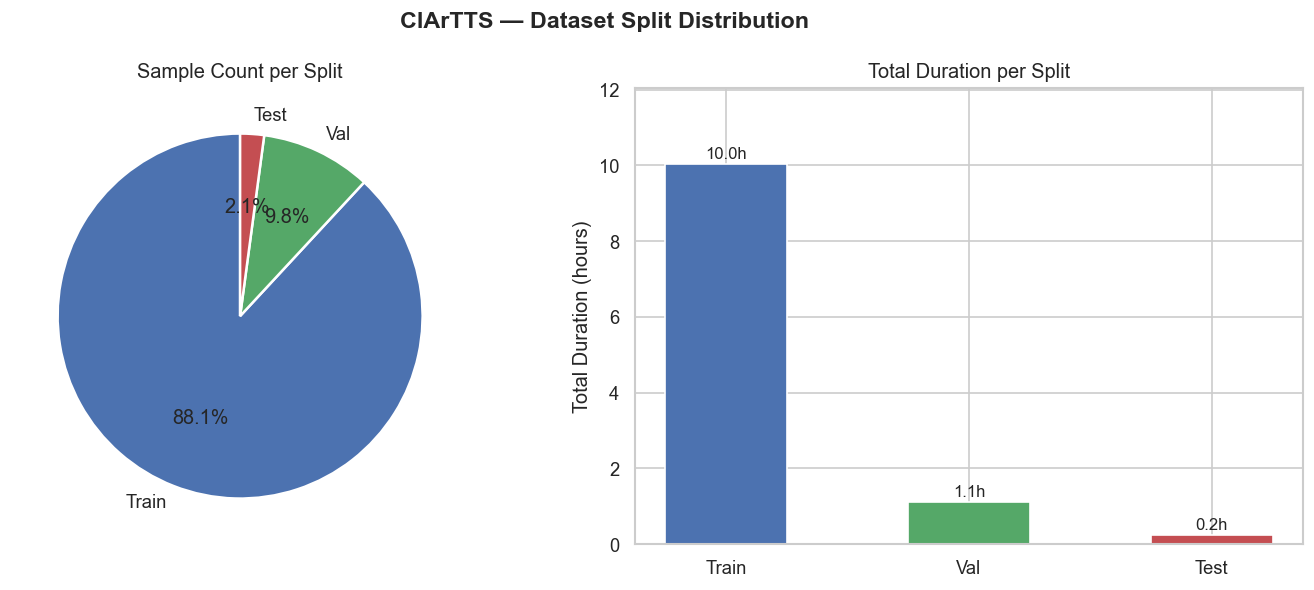

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ClArTTS — Dataset Split Distribution', fontsize=14, fontweight='bold')

split_counts = clartts['split'].value_counts().reindex(['train','val','test'])
colors = ['#4C72B0', '#55A868', '#C44E52']

# Pie chart — sample count
axes[0].pie(split_counts.values, labels=split_counts.index.str.title(),
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Sample Count per Split')

# Bar chart — duration per split
split_dur = clartts.groupby('split')['duration'].sum().reindex(['train','val','test']) / 3600
bars = axes[1].bar(split_dur.index.str.title(), split_dur.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, split_dur.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}h', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Total Duration (hours)')
axes[1].set_title('Total Duration per Split')
axes[1].set_ylim(0, split_dur.max() * 1.2)

plt.tight_layout()
plt.savefig('eda_clartts_splits.png', bbox_inches='tight')
plt.show()

### 4.2 Audio Duration Distributions

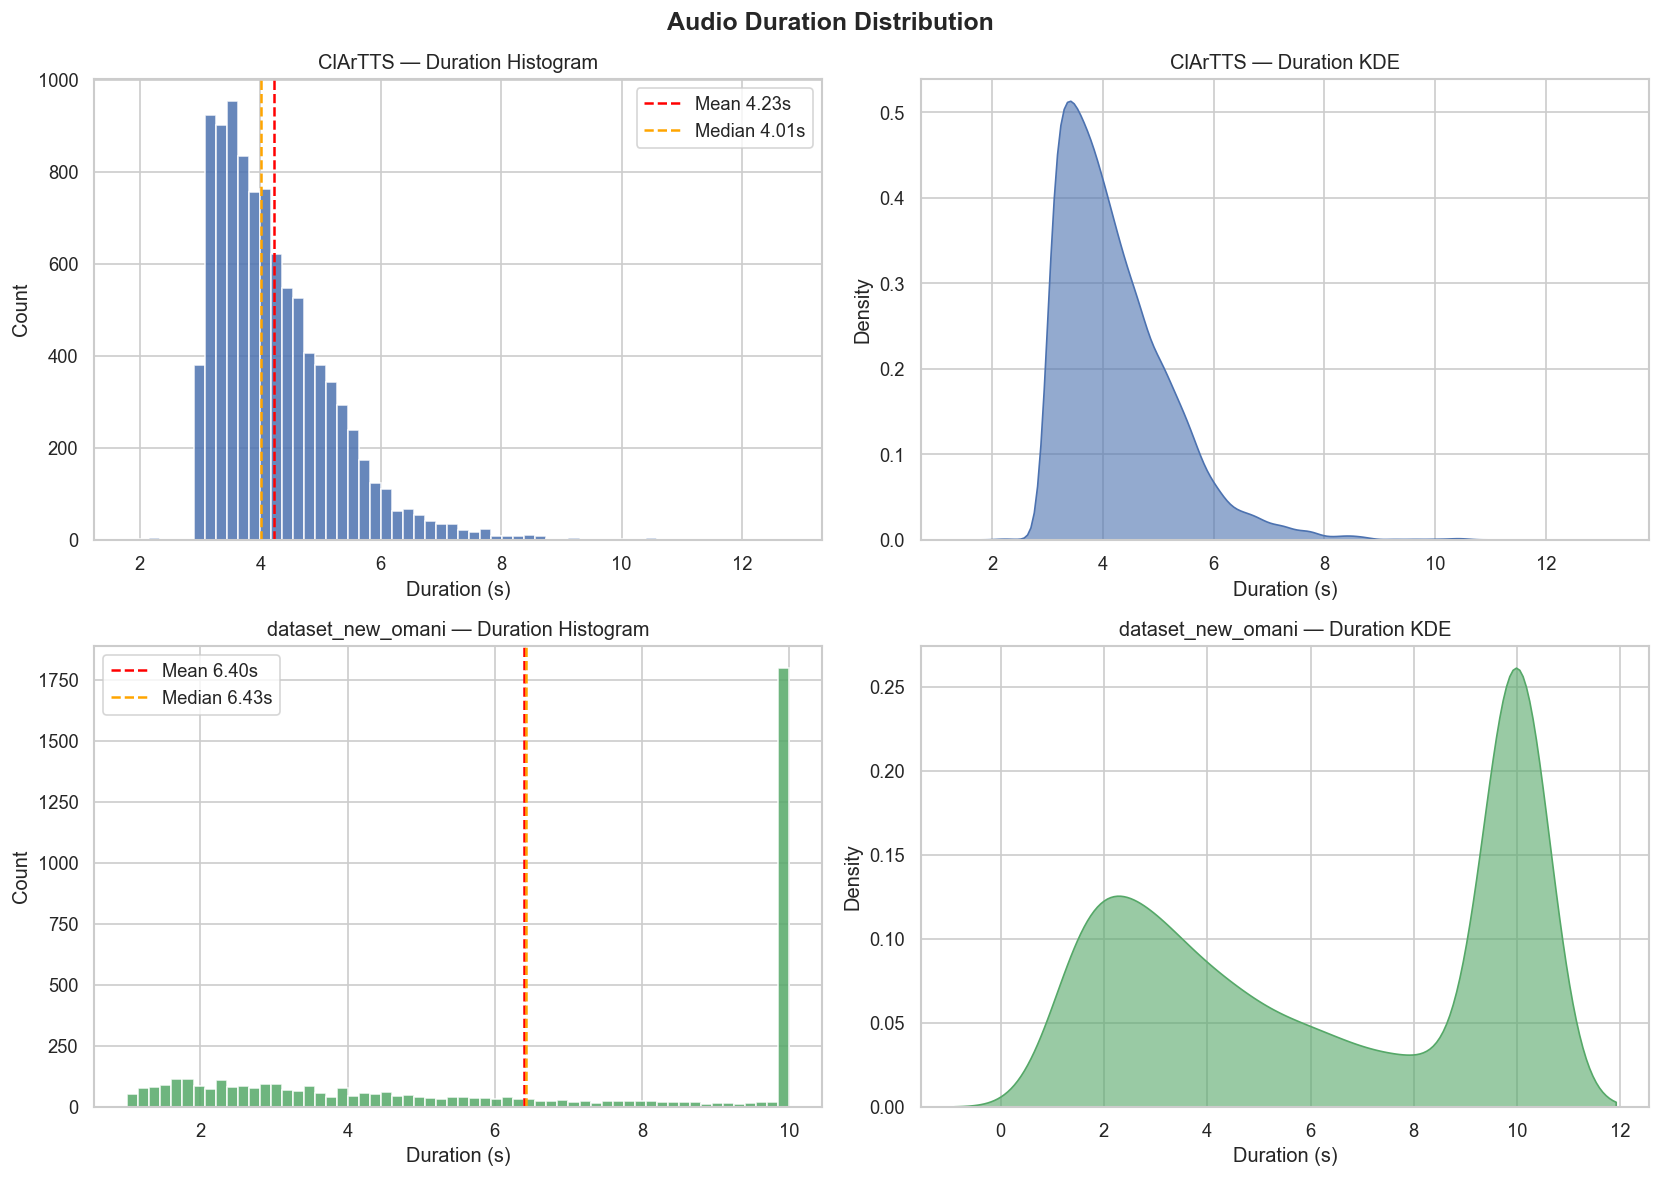

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Audio Duration Distribution', fontsize=15, fontweight='bold')

# ClArTTS — histogram
ax = axes[0, 0]
ax.hist(clartts['duration'], bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(clartts['duration'].mean(), color='red', ls='--', lw=1.5, label=f"Mean {clartts['duration'].mean():.2f}s")
ax.axvline(clartts['duration'].median(), color='orange', ls='--', lw=1.5, label=f"Median {clartts['duration'].median():.2f}s")
ax.set_title('ClArTTS — Duration Histogram')
ax.set_xlabel('Duration (s)'); ax.set_ylabel('Count')
ax.legend()

# ClArTTS — KDE
ax = axes[0, 1]
sns.kdeplot(clartts['duration'], ax=ax, fill=True, color='#4C72B0', alpha=0.6)
ax.set_title('ClArTTS — Duration KDE')
ax.set_xlabel('Duration (s)'); ax.set_ylabel('Density')

# Omani — histogram
ax = axes[1, 0]
ax.hist(omani['duration'], bins=60, color='#55A868', edgecolor='white', alpha=0.85)
ax.axvline(omani['duration'].mean(), color='red', ls='--', lw=1.5, label=f"Mean {omani['duration'].mean():.2f}s")
ax.axvline(omani['duration'].median(), color='orange', ls='--', lw=1.5, label=f"Median {omani['duration'].median():.2f}s")
ax.set_title('dataset_new_omani — Duration Histogram')
ax.set_xlabel('Duration (s)'); ax.set_ylabel('Count')
ax.legend()

# Omani — KDE
ax = axes[1, 1]
sns.kdeplot(omani['duration'], ax=ax, fill=True, color='#55A868', alpha=0.6)
ax.set_title('dataset_new_omani — Duration KDE')
ax.set_xlabel('Duration (s)'); ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('eda_duration_distributions.png', bbox_inches='tight')
plt.show()

### 4.3 Duration — Box Plots (Both Datasets Side-by-Side)

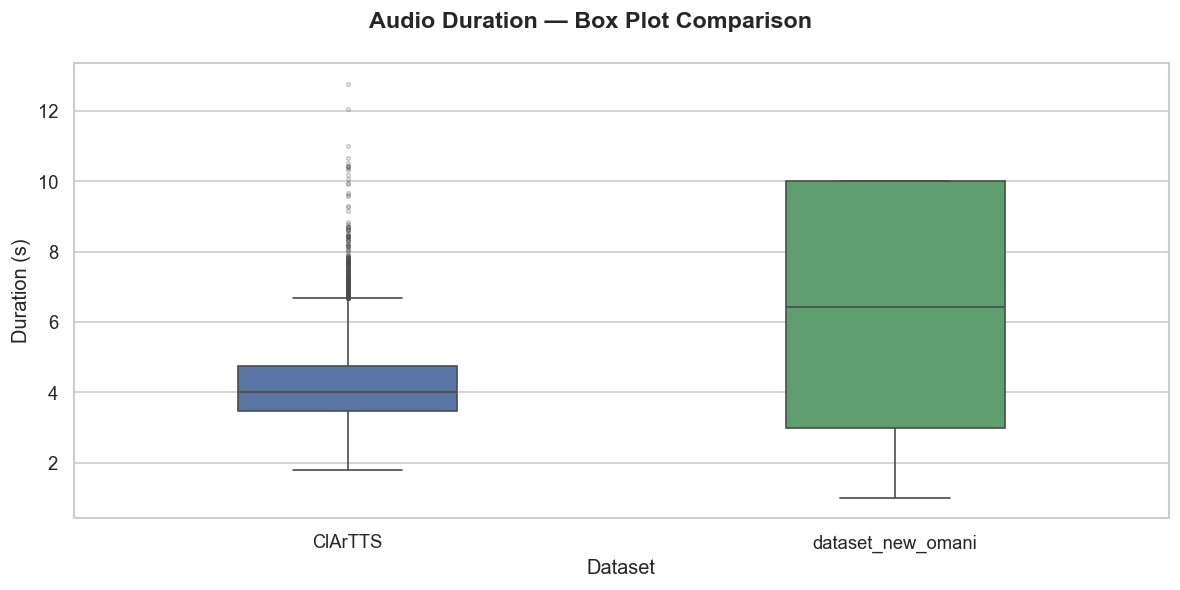

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Audio Duration — Box Plot Comparison', fontsize=14, fontweight='bold')

combined_box = pd.DataFrame({
    'Duration (s)': pd.concat([clartts['duration'], omani['duration']], ignore_index=True),
    'Dataset':      ['ClArTTS'] * len(clartts) + ['dataset_new_omani'] * len(omani)
})

sns.boxplot(data=combined_box, x='Dataset', y='Duration (s)',
            palette=['#4C72B0', '#55A868'], width=0.4, ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_title('')

plt.tight_layout()
plt.savefig('eda_duration_boxplot.png', bbox_inches='tight')
plt.show()

### 4.4 Duration Bins — Category Distribution

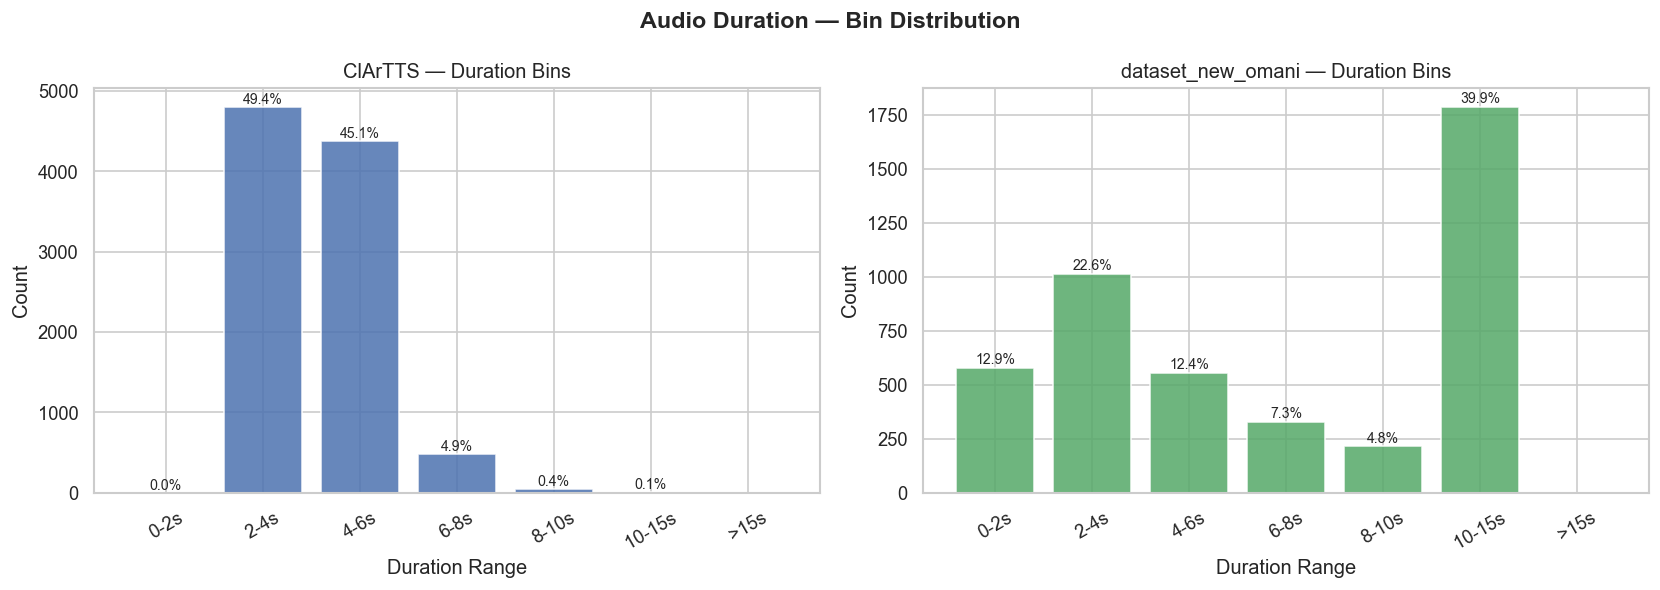

In [12]:
bins   = [0, 2, 4, 6, 8, 10, 15, 100]
labels = ['0-2s', '2-4s', '4-6s', '6-8s', '8-10s', '10-15s', '>15s']

clartts['dur_bin'] = pd.cut(clartts['duration'], bins=bins, labels=labels, right=False)
omani['dur_bin']   = pd.cut(omani['duration'],   bins=bins, labels=labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Audio Duration — Bin Distribution', fontsize=14, fontweight='bold')

for ax, df, title, color in zip(axes,
                                  [clartts, omani],
                                  ['ClArTTS', 'dataset_new_omani'],
                                  ['#4C72B0', '#55A868']):
    counts = df['dur_bin'].value_counts().reindex(labels, fill_value=0)
    pcts   = 100 * counts / counts.sum()
    bars = ax.bar(labels, counts.values, color=color, edgecolor='white', alpha=0.85)
    for bar, pct in zip(bars, pcts):
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=8.5)
    ax.set_title(f'{title} — Duration Bins')
    ax.set_xlabel('Duration Range')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_duration_bins.png', bbox_inches='tight')
plt.show()

### 4.5 Text Length Distributions (Character & Word Count)

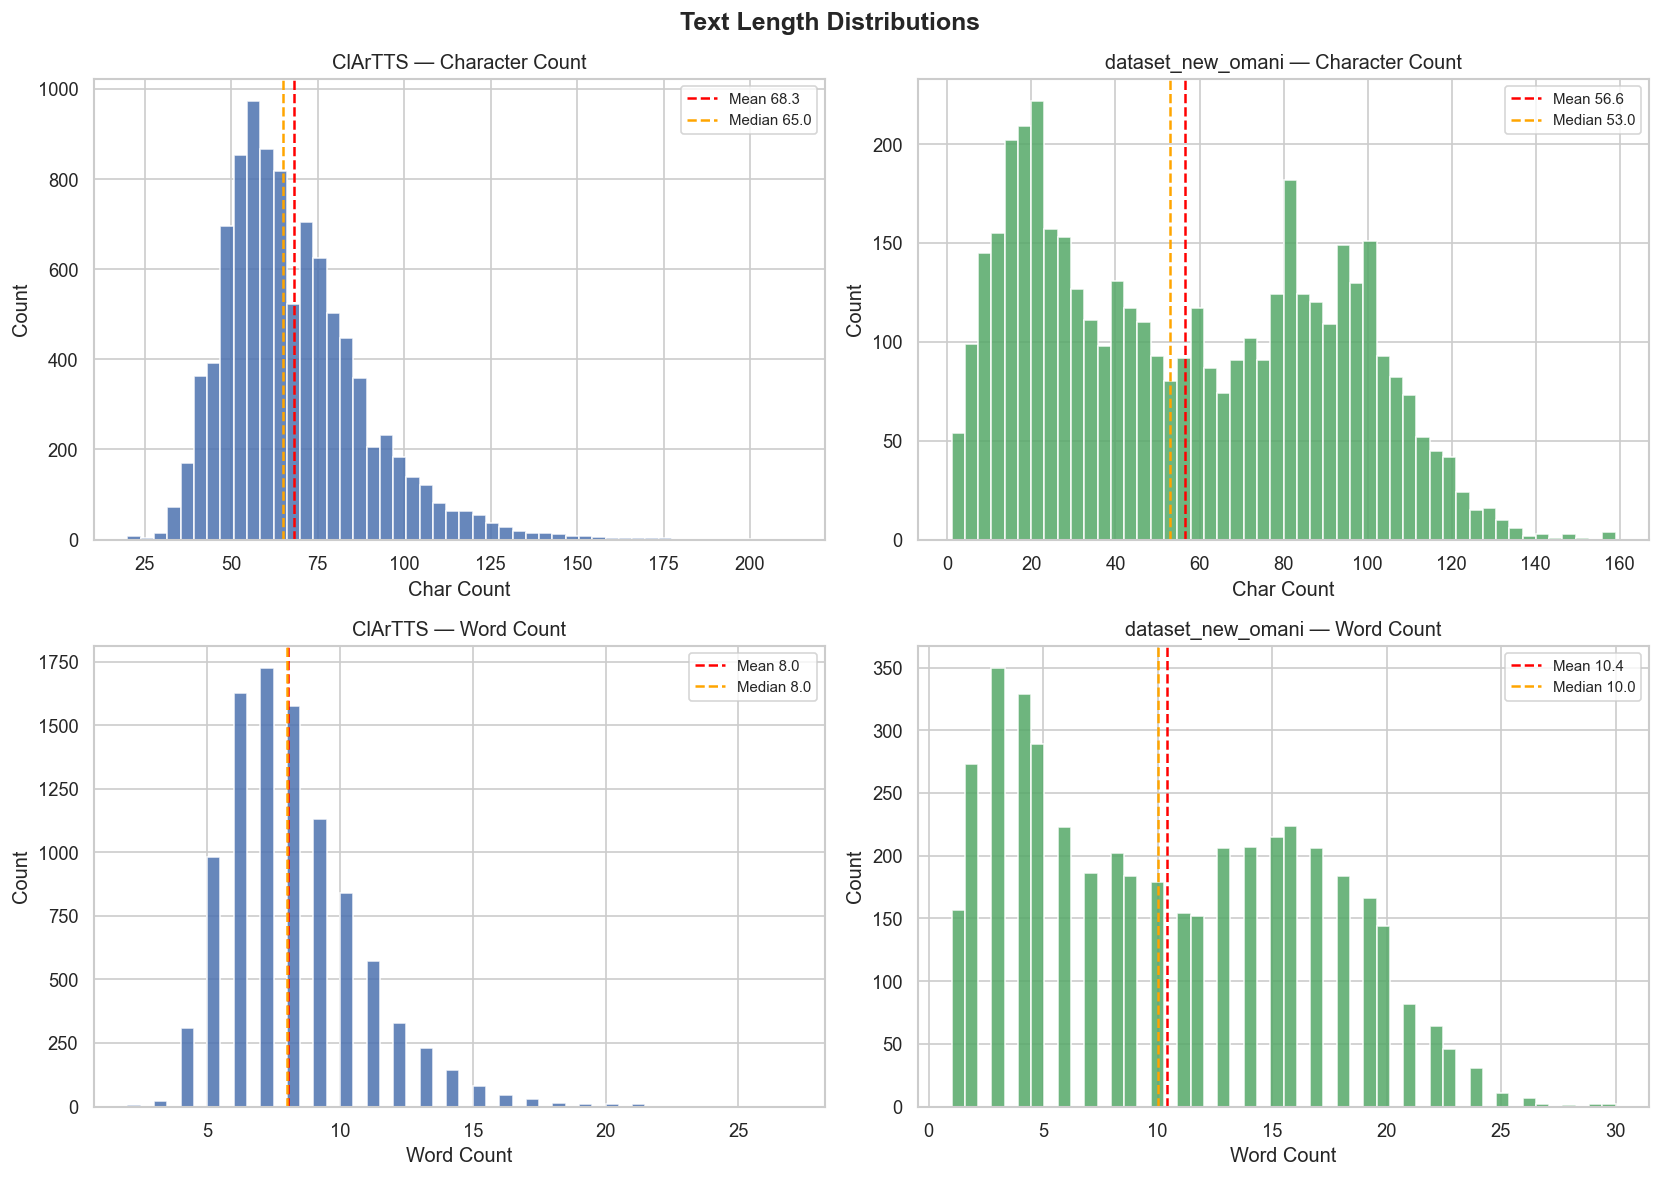

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Text Length Distributions', fontsize=15, fontweight='bold')

pairs = [
    (axes[0, 0], clartts, 'char_count', 'ClArTTS — Character Count', '#4C72B0'),
    (axes[0, 1], omani,   'char_count', 'dataset_new_omani — Character Count', '#55A868'),
    (axes[1, 0], clartts, 'word_count', 'ClArTTS — Word Count', '#4C72B0'),
    (axes[1, 1], omani,   'word_count', 'dataset_new_omani — Word Count', '#55A868'),
]

for ax, df, col, title, color in pairs:
    ax.hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    ls='--', lw=1.5, label=f'Mean {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', ls='--', lw=1.5, label=f'Median {df[col].median():.1f}')
    ax.set_title(title)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_text_length_distributions.png', bbox_inches='tight')
plt.show()

### 4.6 Duration vs. Text Length Scatter

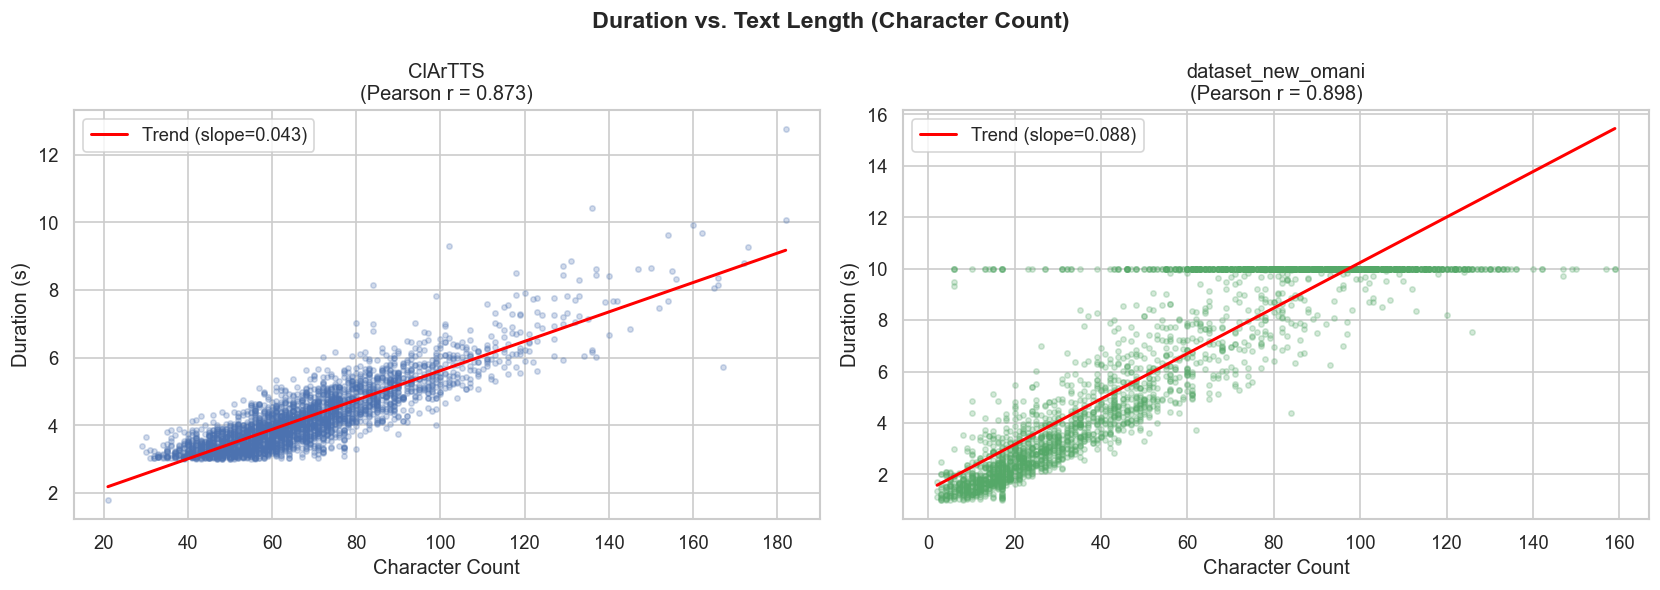

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Duration vs. Text Length (Character Count)', fontsize=14, fontweight='bold')

for ax, df, title, color in zip(axes,
                                  [clartts, omani],
                                  ['ClArTTS', 'dataset_new_omani'],
                                  ['#4C72B0', '#55A868']):
    # Sample for performance
    sample = df.sample(min(3000, len(df)), random_state=42)
    ax.scatter(sample['char_count'], sample['duration'], alpha=0.25, s=10, color=color)
    
    # Trend line
    z = np.polyfit(sample['char_count'], sample['duration'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sample['char_count'].min(), sample['char_count'].max(), 200)
    ax.plot(xs, p(xs), color='red', lw=1.8, label=f'Trend (slope={z[0]:.3f})')
    
    corr = df['char_count'].corr(df['duration'])
    ax.set_title(f'{title}\n(Pearson r = {corr:.3f})')
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Duration (s)')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_duration_vs_chars.png', bbox_inches='tight')
plt.show()

### 4.7 Duration vs. Word Count Scatter

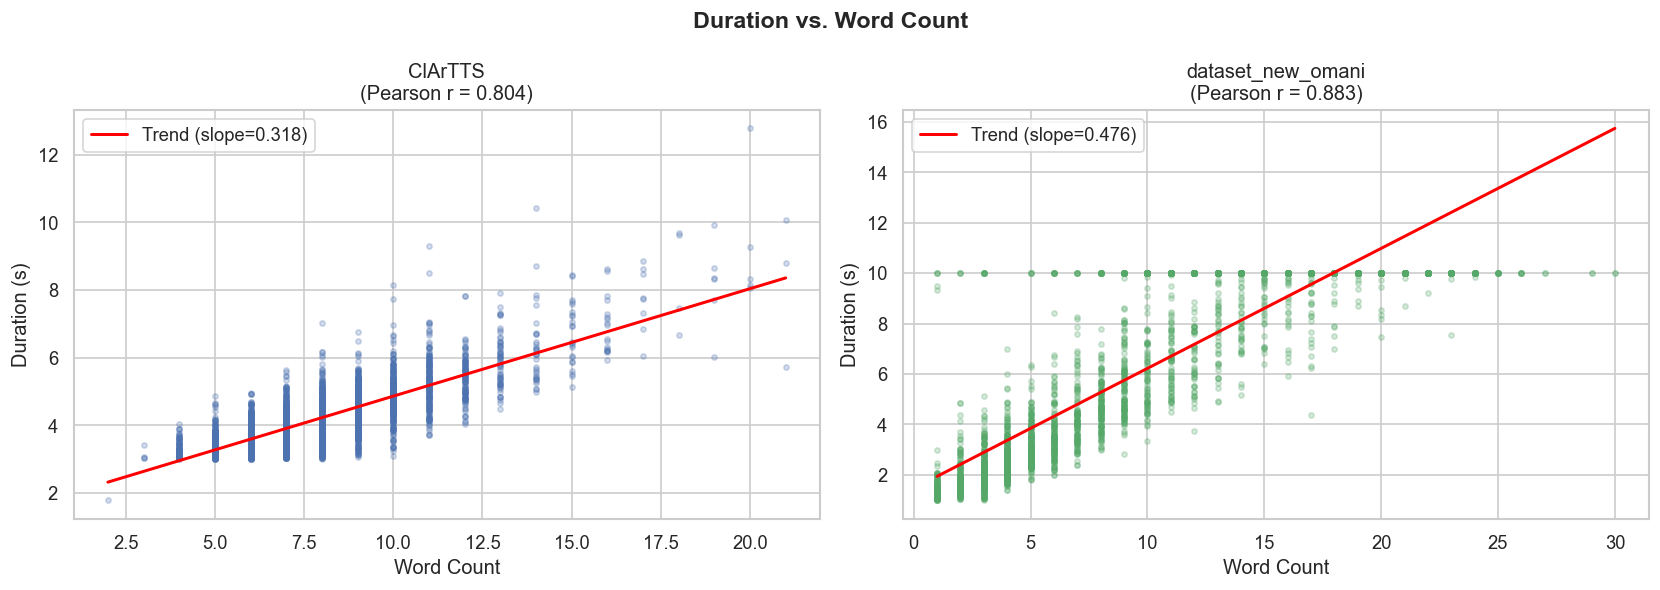

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Duration vs. Word Count', fontsize=14, fontweight='bold')

for ax, df, title, color in zip(axes,
                                  [clartts, omani],
                                  ['ClArTTS', 'dataset_new_omani'],
                                  ['#4C72B0', '#55A868']):
    sample = df.sample(min(3000, len(df)), random_state=42)
    ax.scatter(sample['word_count'], sample['duration'], alpha=0.25, s=10, color=color)
    z = np.polyfit(sample['word_count'], sample['duration'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sample['word_count'].min(), sample['word_count'].max(), 200)
    ax.plot(xs, p(xs), color='red', lw=1.8, label=f'Trend (slope={z[0]:.3f})')
    corr = df['word_count'].corr(df['duration'])
    ax.set_title(f'{title}\n(Pearson r = {corr:.3f})')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Duration (s)')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_duration_vs_words.png', bbox_inches='tight')
plt.show()

### 4.8 Correlation Heatmaps

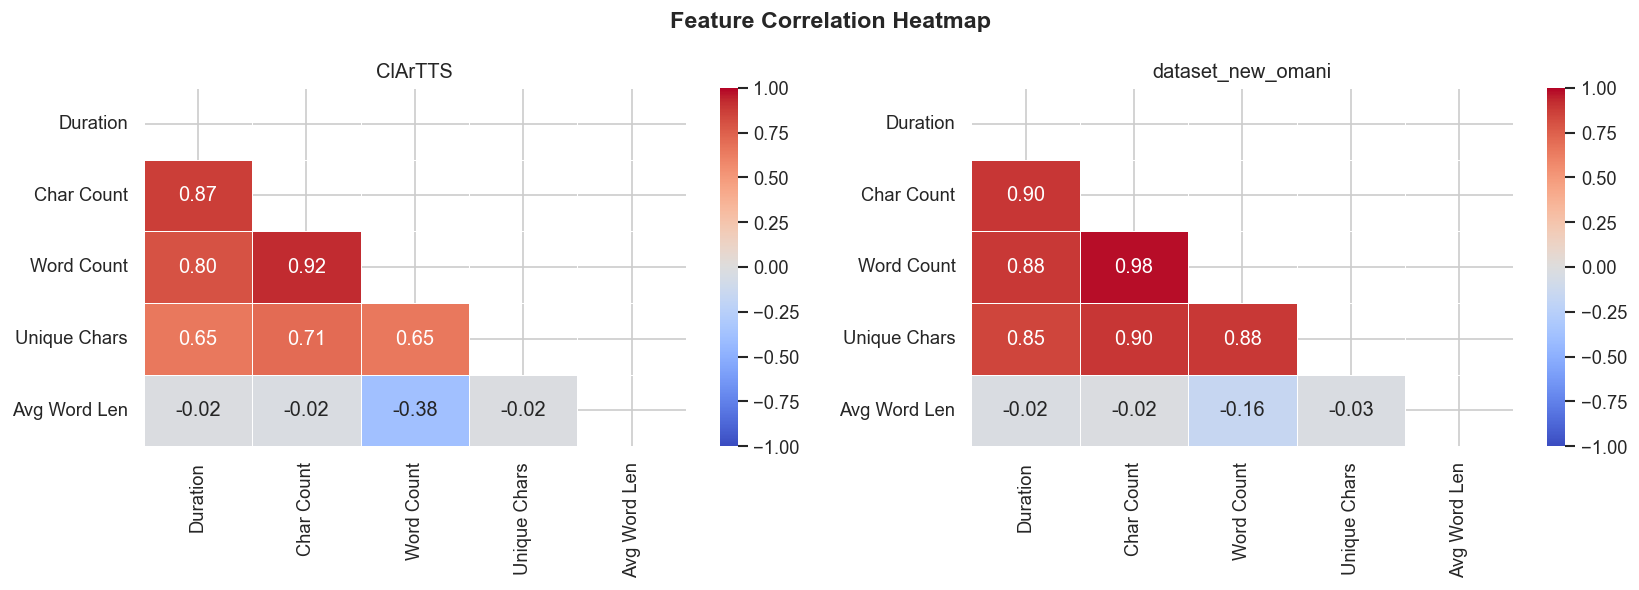

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

num_cols = ['duration', 'char_count', 'word_count', 'unique_chars', 'avg_word_len']

for ax, df, title in zip(axes, [clartts, omani], ['ClArTTS', 'dataset_new_omani']):
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                mask=mask, vmin=-1, vmax=1, linewidths=0.5,
                xticklabels=[c.replace('_',' ').title() for c in num_cols],
                yticklabels=[c.replace('_',' ').title() for c in num_cols])
    ax.set_title(title)

plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 4.9 Characters per Second (Speaking Rate)

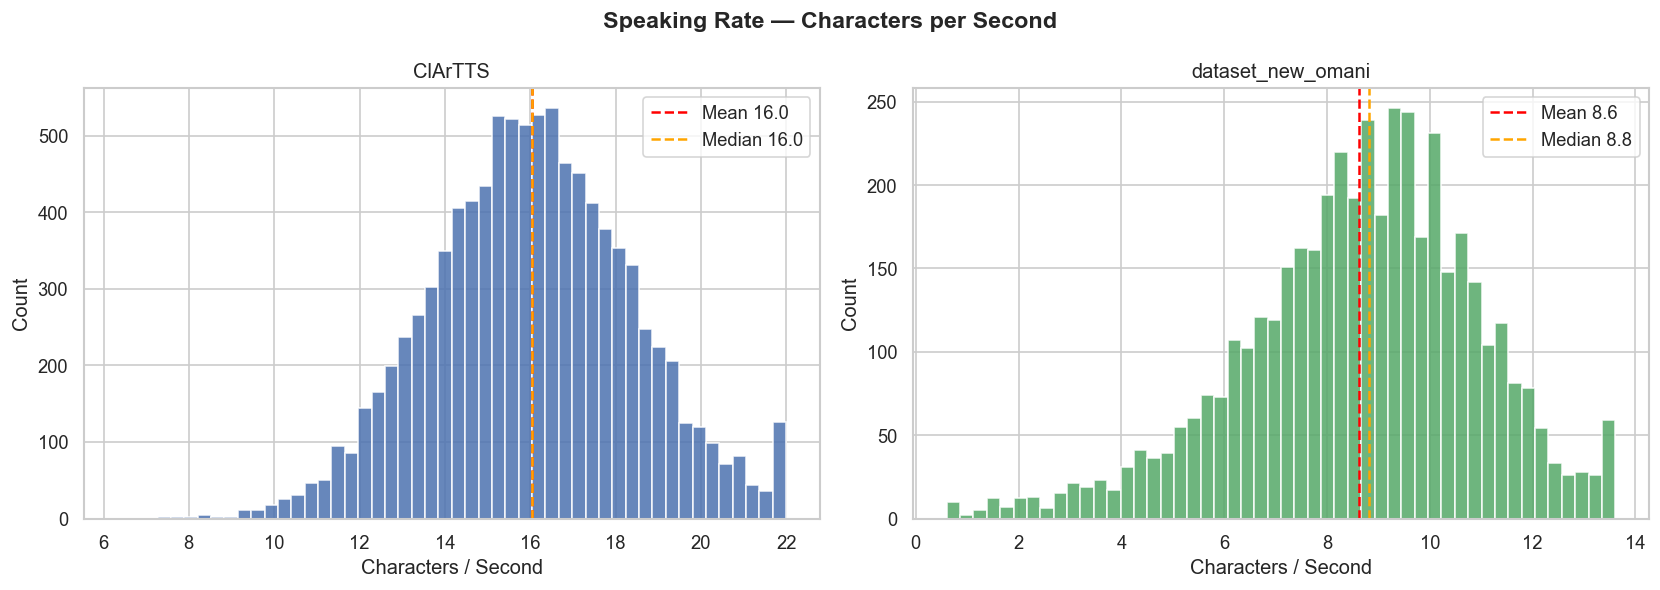

In [17]:
clartts['chars_per_sec'] = clartts['char_count'] / clartts['duration'].clip(lower=0.1)
omani['chars_per_sec']   = omani['char_count']   / omani['duration'].clip(lower=0.1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Speaking Rate — Characters per Second', fontsize=14, fontweight='bold')

for ax, df, title, color in zip(axes,
                                  [clartts, omani],
                                  ['ClArTTS', 'dataset_new_omani'],
                                  ['#4C72B0', '#55A868']):
    data = df['chars_per_sec'].clip(0, df['chars_per_sec'].quantile(0.99))
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    ls='--', lw=1.5, label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', ls='--', lw=1.5, label=f'Median {data.median():.1f}')
    ax.set_title(title)
    ax.set_xlabel('Characters / Second')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_speaking_rate.png', bbox_inches='tight')
plt.show()

### 4.10 Cumulative Duration — Both Datasets

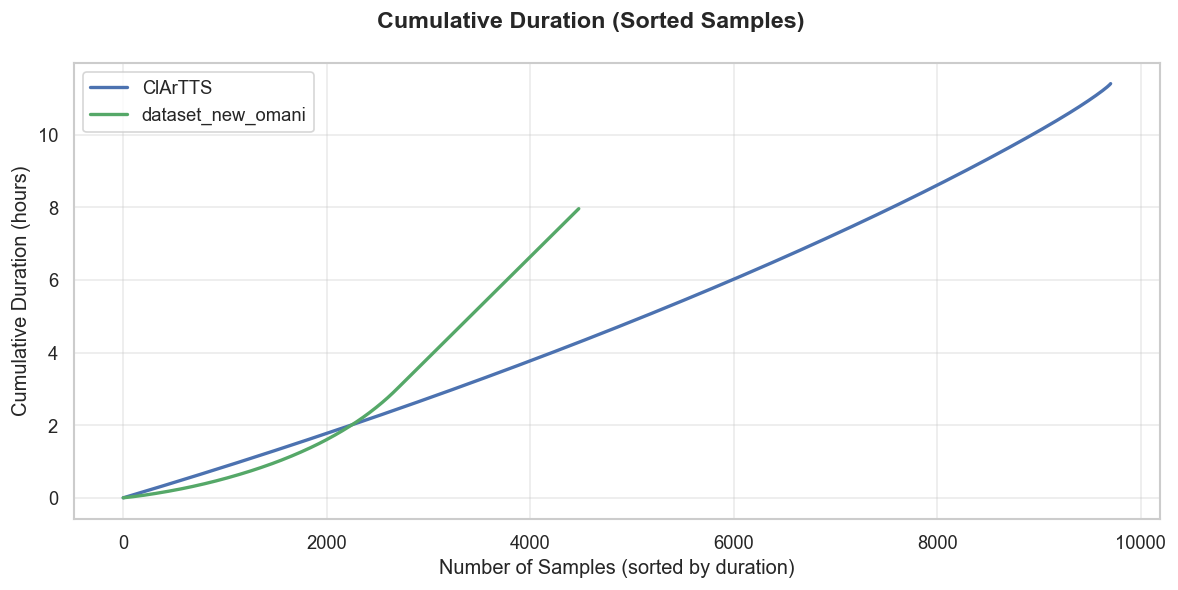

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Cumulative Duration (Sorted Samples)', fontsize=14, fontweight='bold')

for df, label, color in [(clartts, 'ClArTTS', '#4C72B0'), (omani, 'dataset_new_omani', '#55A868')]:
    sorted_dur = df['duration'].sort_values().values
    cumulative = np.cumsum(sorted_dur) / 3600
    ax.plot(np.arange(1, len(sorted_dur)+1), cumulative, label=label, color=color, lw=2)

ax.set_xlabel('Number of Samples (sorted by duration)')
ax.set_ylabel('Cumulative Duration (hours)')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('eda_cumulative_duration.png', bbox_inches='tight')
plt.show()

### 4.11 Top-50 Most Frequent Characters

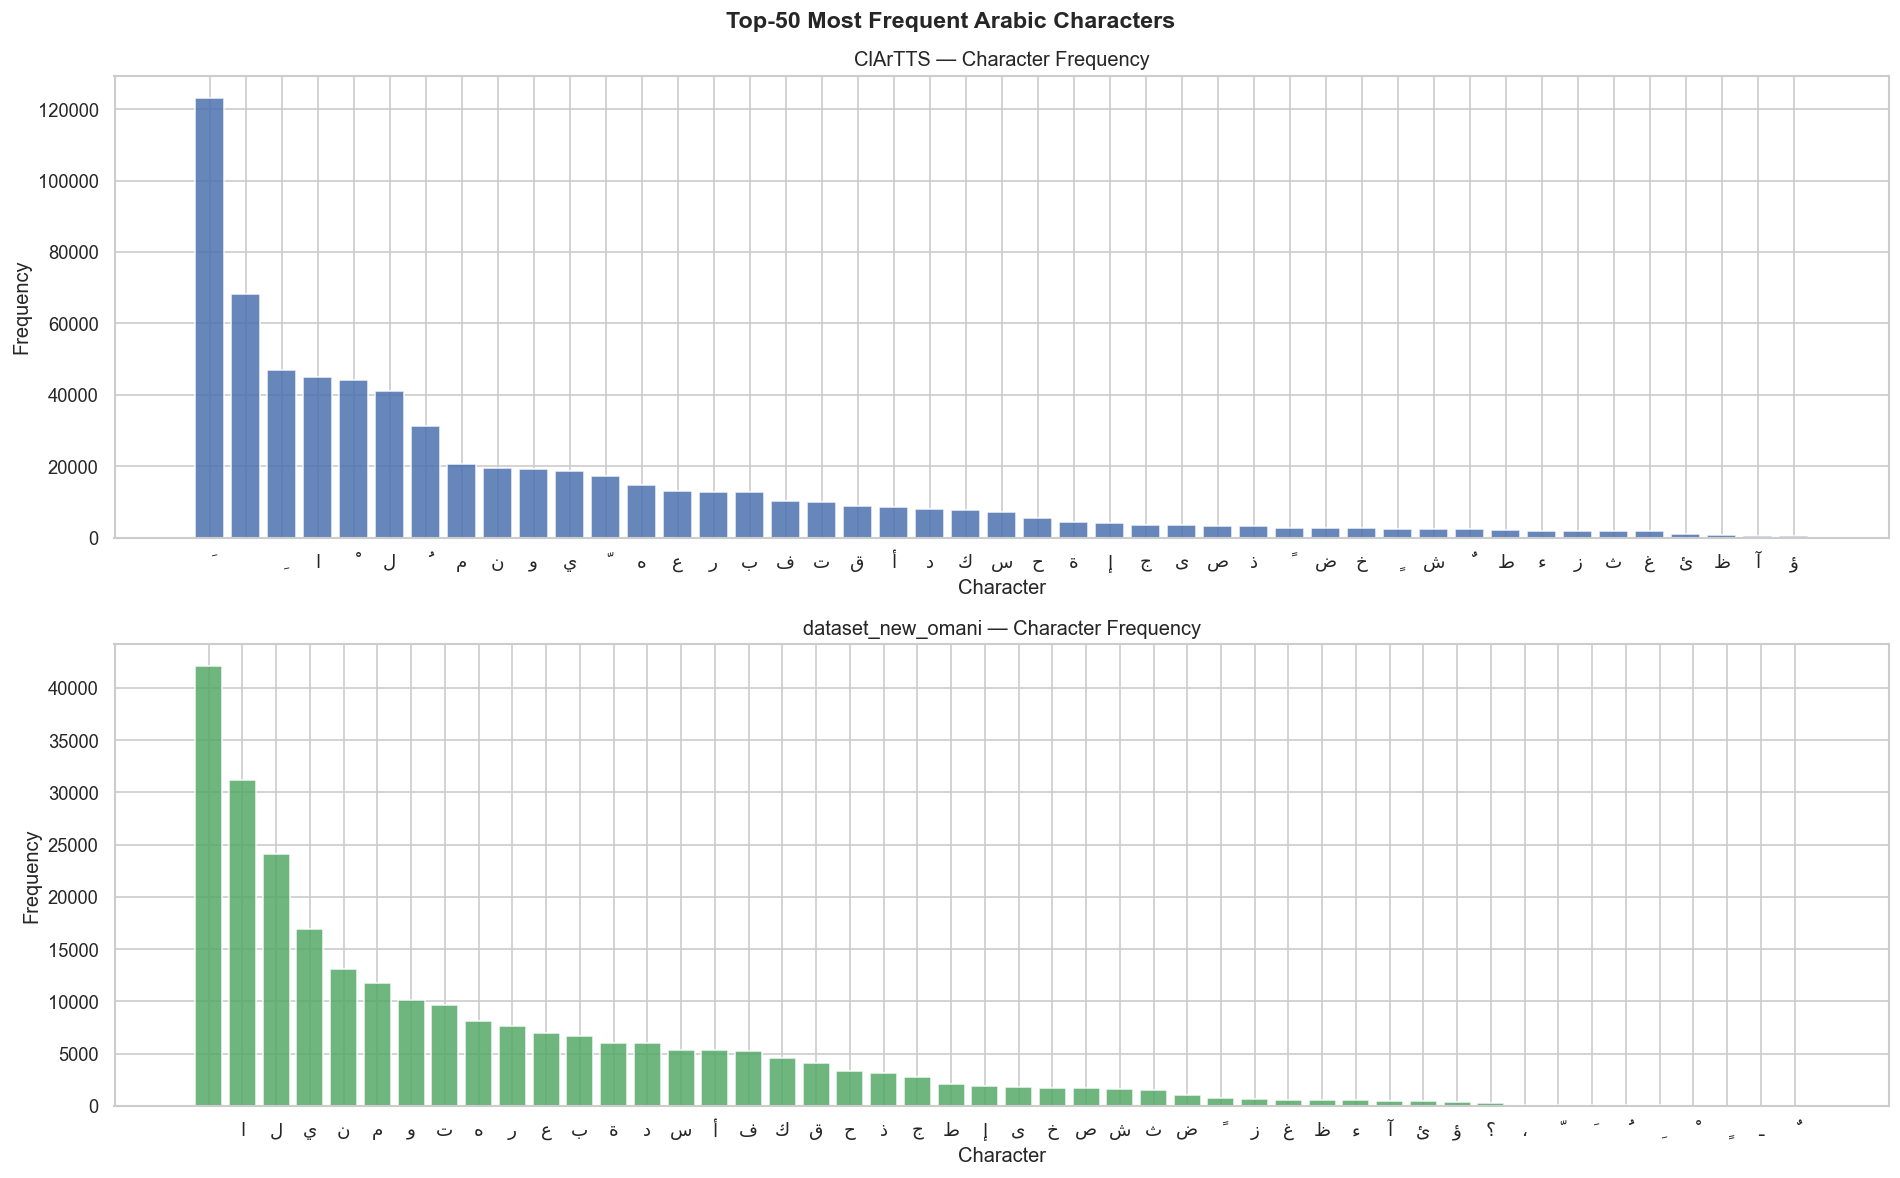

In [19]:
from collections import Counter

def char_freq(df, text_col='text', top_n=50):
    all_chars = ''.join(df[text_col].dropna().astype(str).tolist())
    # Keep only Arabic and space
    all_chars = [c for c in all_chars if '\u0600' <= c <= '\u06FF' or c == ' ']
    counts = Counter(all_chars)
    return pd.DataFrame(counts.most_common(top_n), columns=['char', 'count'])

cf_c = char_freq(clartts)
cf_o = char_freq(omani)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Top-50 Most Frequent Arabic Characters', fontsize=14, fontweight='bold')

for ax, cf, title, color in zip(axes,
                                  [cf_c, cf_o],
                                  ['ClArTTS', 'dataset_new_omani'],
                                  ['#4C72B0', '#55A868']):
    ax.bar(range(len(cf)), cf['count'], color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(cf)))
    ax.set_xticklabels(cf['char'], fontsize=11, fontfamily='DejaVu Sans')
    ax.set_title(f'{title} — Character Frequency')
    ax.set_xlabel('Character')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_char_frequency.png', bbox_inches='tight')
plt.show()

### 4.12 Word Count Distribution — Violin Plot

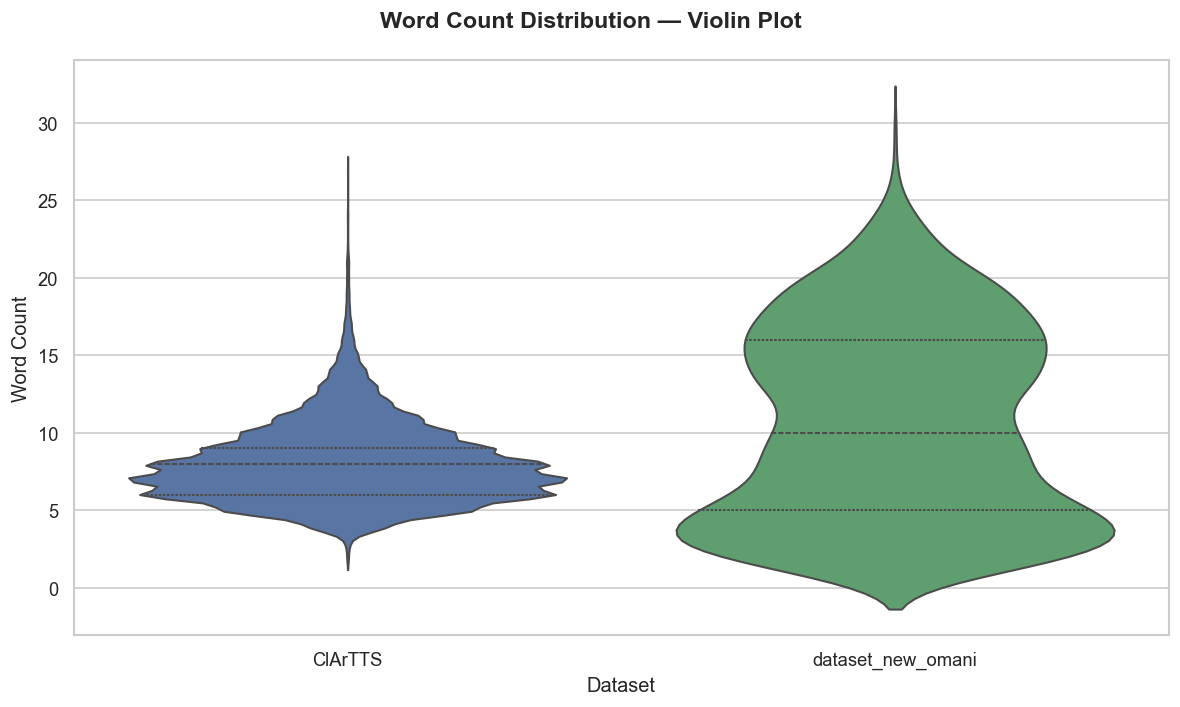

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Word Count Distribution — Violin Plot', fontsize=14, fontweight='bold')

violin_data = pd.DataFrame({
    'Word Count': pd.concat([clartts['word_count'], omani['word_count']], ignore_index=True),
    'Dataset':    ['ClArTTS'] * len(clartts) + ['dataset_new_omani'] * len(omani)
})

sns.violinplot(data=violin_data, x='Dataset', y='Word Count',
               palette=['#4C72B0', '#55A868'], inner='quartile', ax=ax)

plt.tight_layout()
plt.savefig('eda_wordcount_violin.png', bbox_inches='tight')
plt.show()

### 4.13 Sample Mel Spectrograms

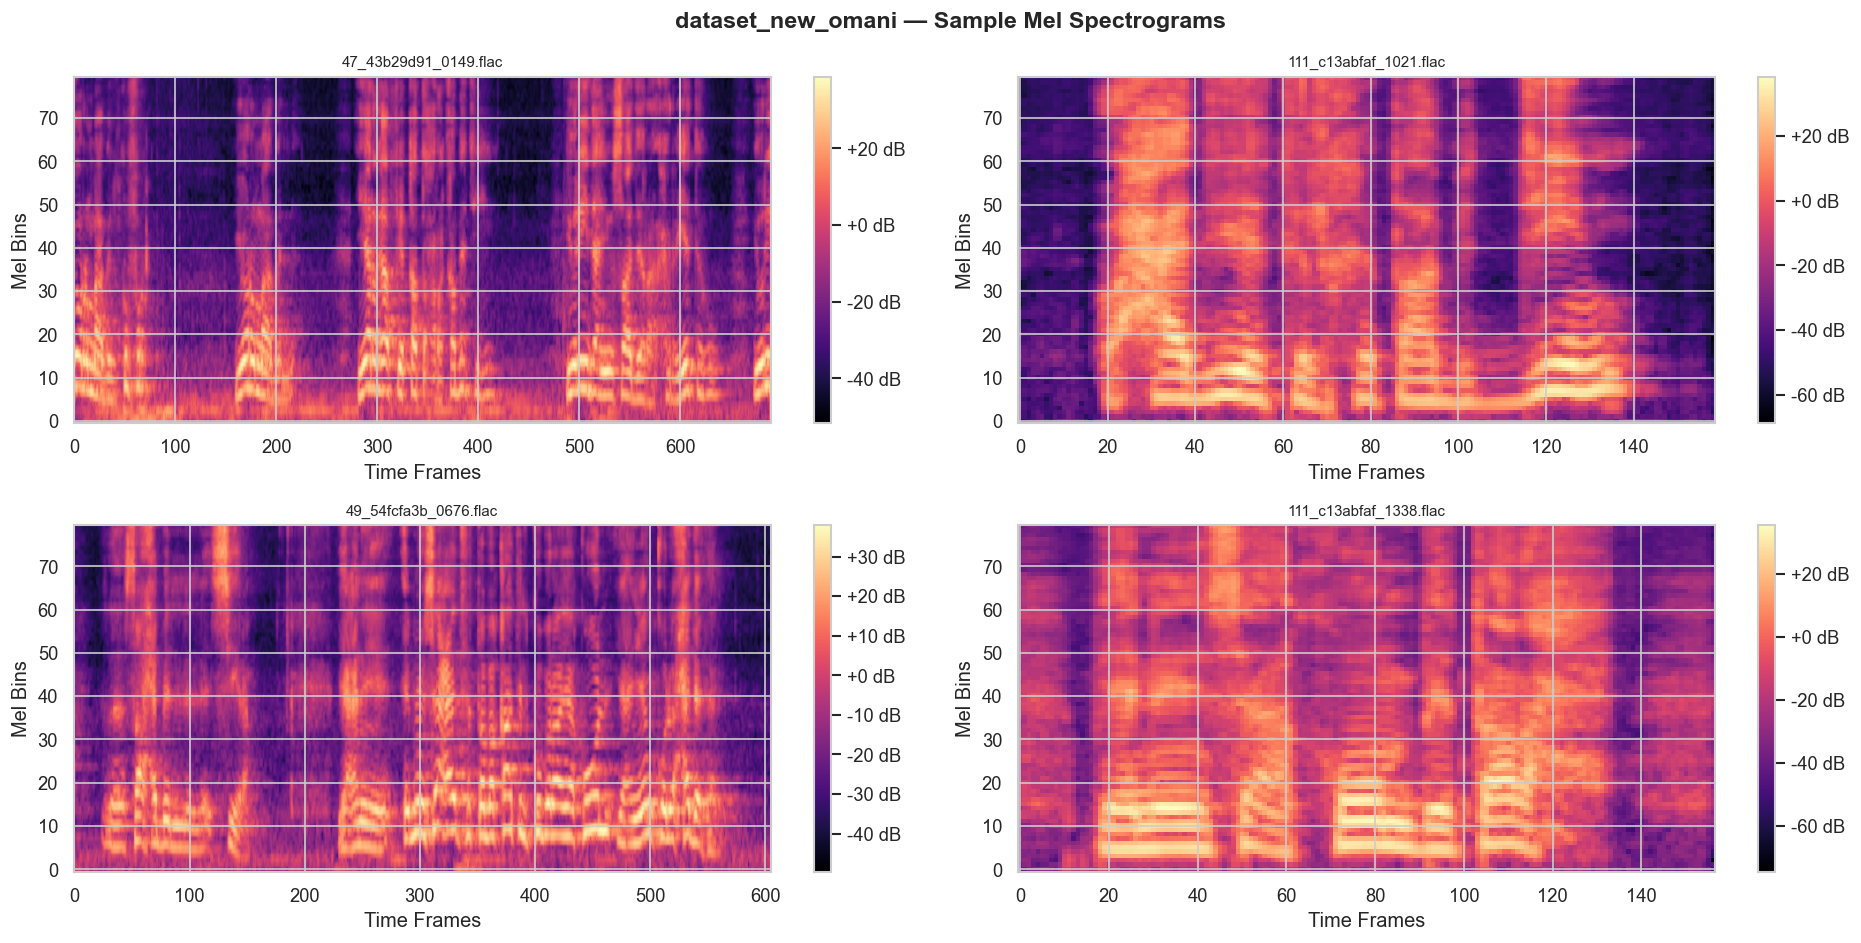

In [21]:
import torch
import torchaudio.functional as TAF

SR = 22050
N_MELS = 80
N_FFT = 1024
HOP = 256

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP,
    n_mels=N_MELS, f_min=0, f_max=8000
)

def load_and_mel(path, max_sec=8.0):
    wav, sr = torchaudio.load(path)
    if sr != SR:
        wav = TAF.resample(wav, sr, SR)
    wav = wav[:, :int(max_sec * SR)]
    mel = mel_transform(wav[0])
    mel_db = torchaudio.transforms.AmplitudeToDB()(mel)
    return mel_db.numpy()

# Pick 4 samples from Omani
omani_samples = omani['file_path'].dropna().sample(4, random_state=1).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('dataset_new_omani — Sample Mel Spectrograms', fontsize=14, fontweight='bold')

for ax, path in zip(axes.flat, omani_samples):
    mel = load_and_mel(path)
    img = ax.imshow(mel, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.set_xlabel('Time Frames')
    ax.set_ylabel('Mel Bins')
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.savefig('eda_omani_mel_spectrograms.png', bbox_inches='tight')
plt.show()

### 4.14 Sample Waveforms

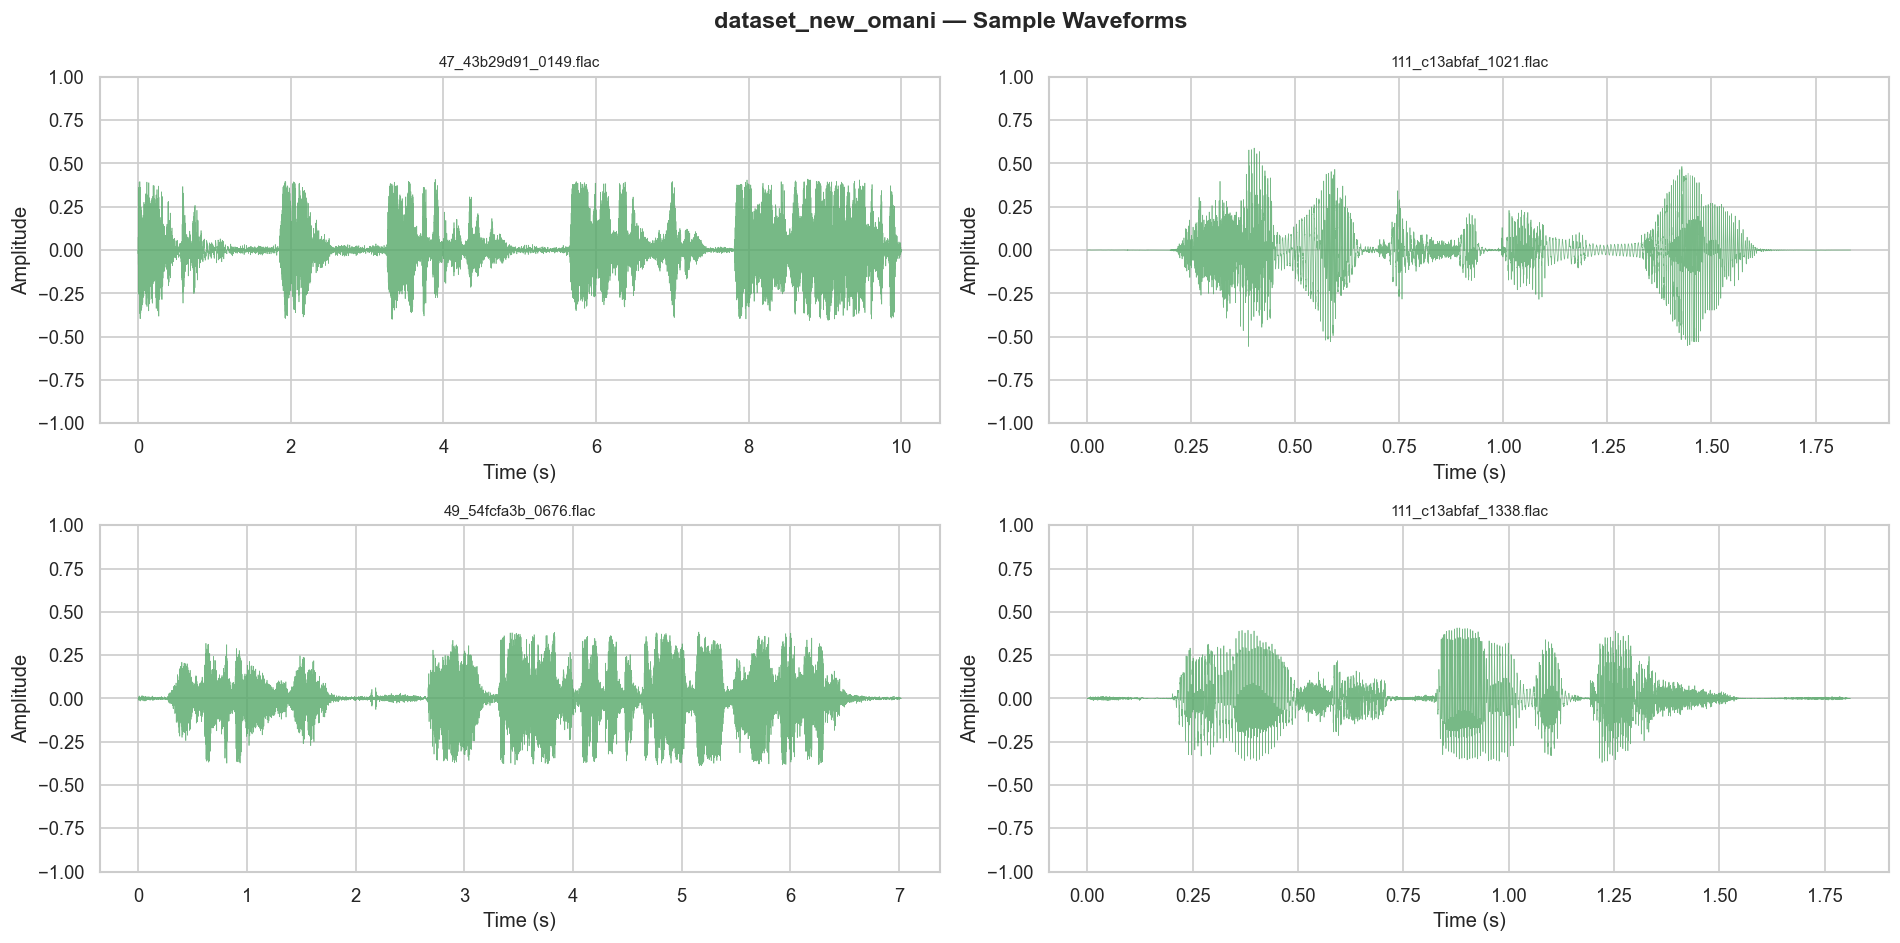

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('dataset_new_omani — Sample Waveforms', fontsize=14, fontweight='bold')

for ax, path in zip(axes.flat, omani_samples):
    wav, sr = torchaudio.load(path)
    if sr != SR:
        wav = TAF.resample(wav, sr, SR)
    wav_np = wav[0].numpy()
    t = np.linspace(0, len(wav_np)/SR, len(wav_np))
    ax.plot(t, wav_np, color='#55A868', lw=0.4, alpha=0.8)
    ax.set_title(os.path.basename(path), fontsize=9)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('eda_omani_waveforms.png', bbox_inches='tight')
plt.show()

### 4.15 ClArTTS — Duration by Split (Box Plot)

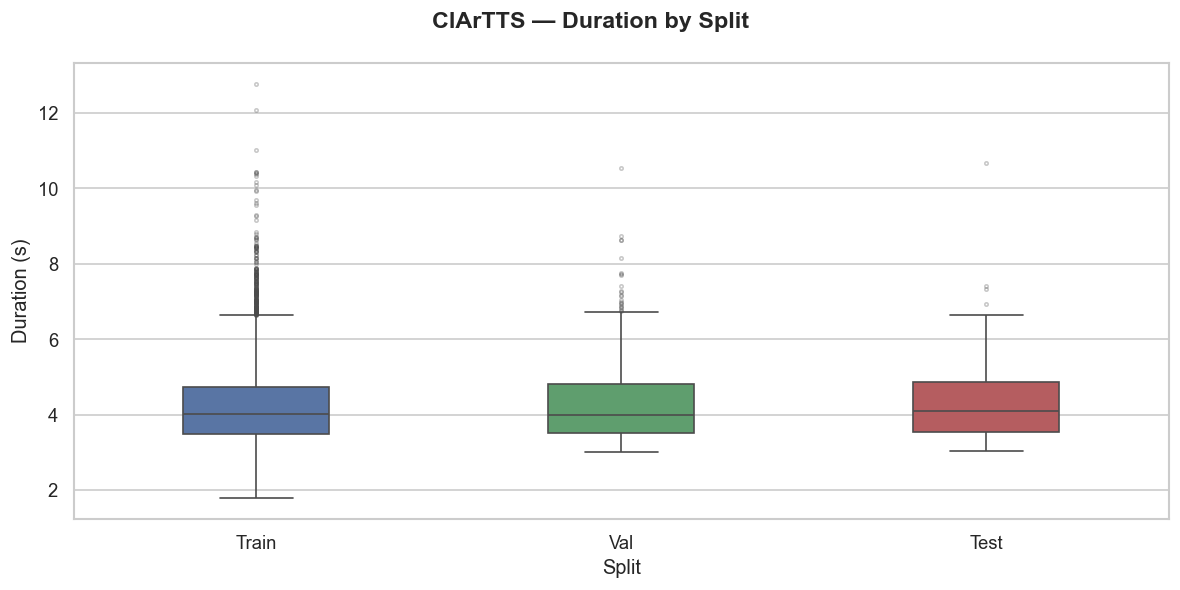

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('ClArTTS — Duration by Split', fontsize=14, fontweight='bold')

clartts['Split'] = clartts['split'].str.title()
sns.boxplot(data=clartts, x='Split', y='duration', order=['Train', 'Val', 'Test'],
            palette=['#4C72B0', '#55A868', '#C44E52'], width=0.4, ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_ylabel('Duration (s)')
ax.set_xlabel('Split')

plt.tight_layout()
plt.savefig('eda_clartts_duration_by_split.png', bbox_inches='tight')
plt.show()

### 4.16 Summary Dashboard

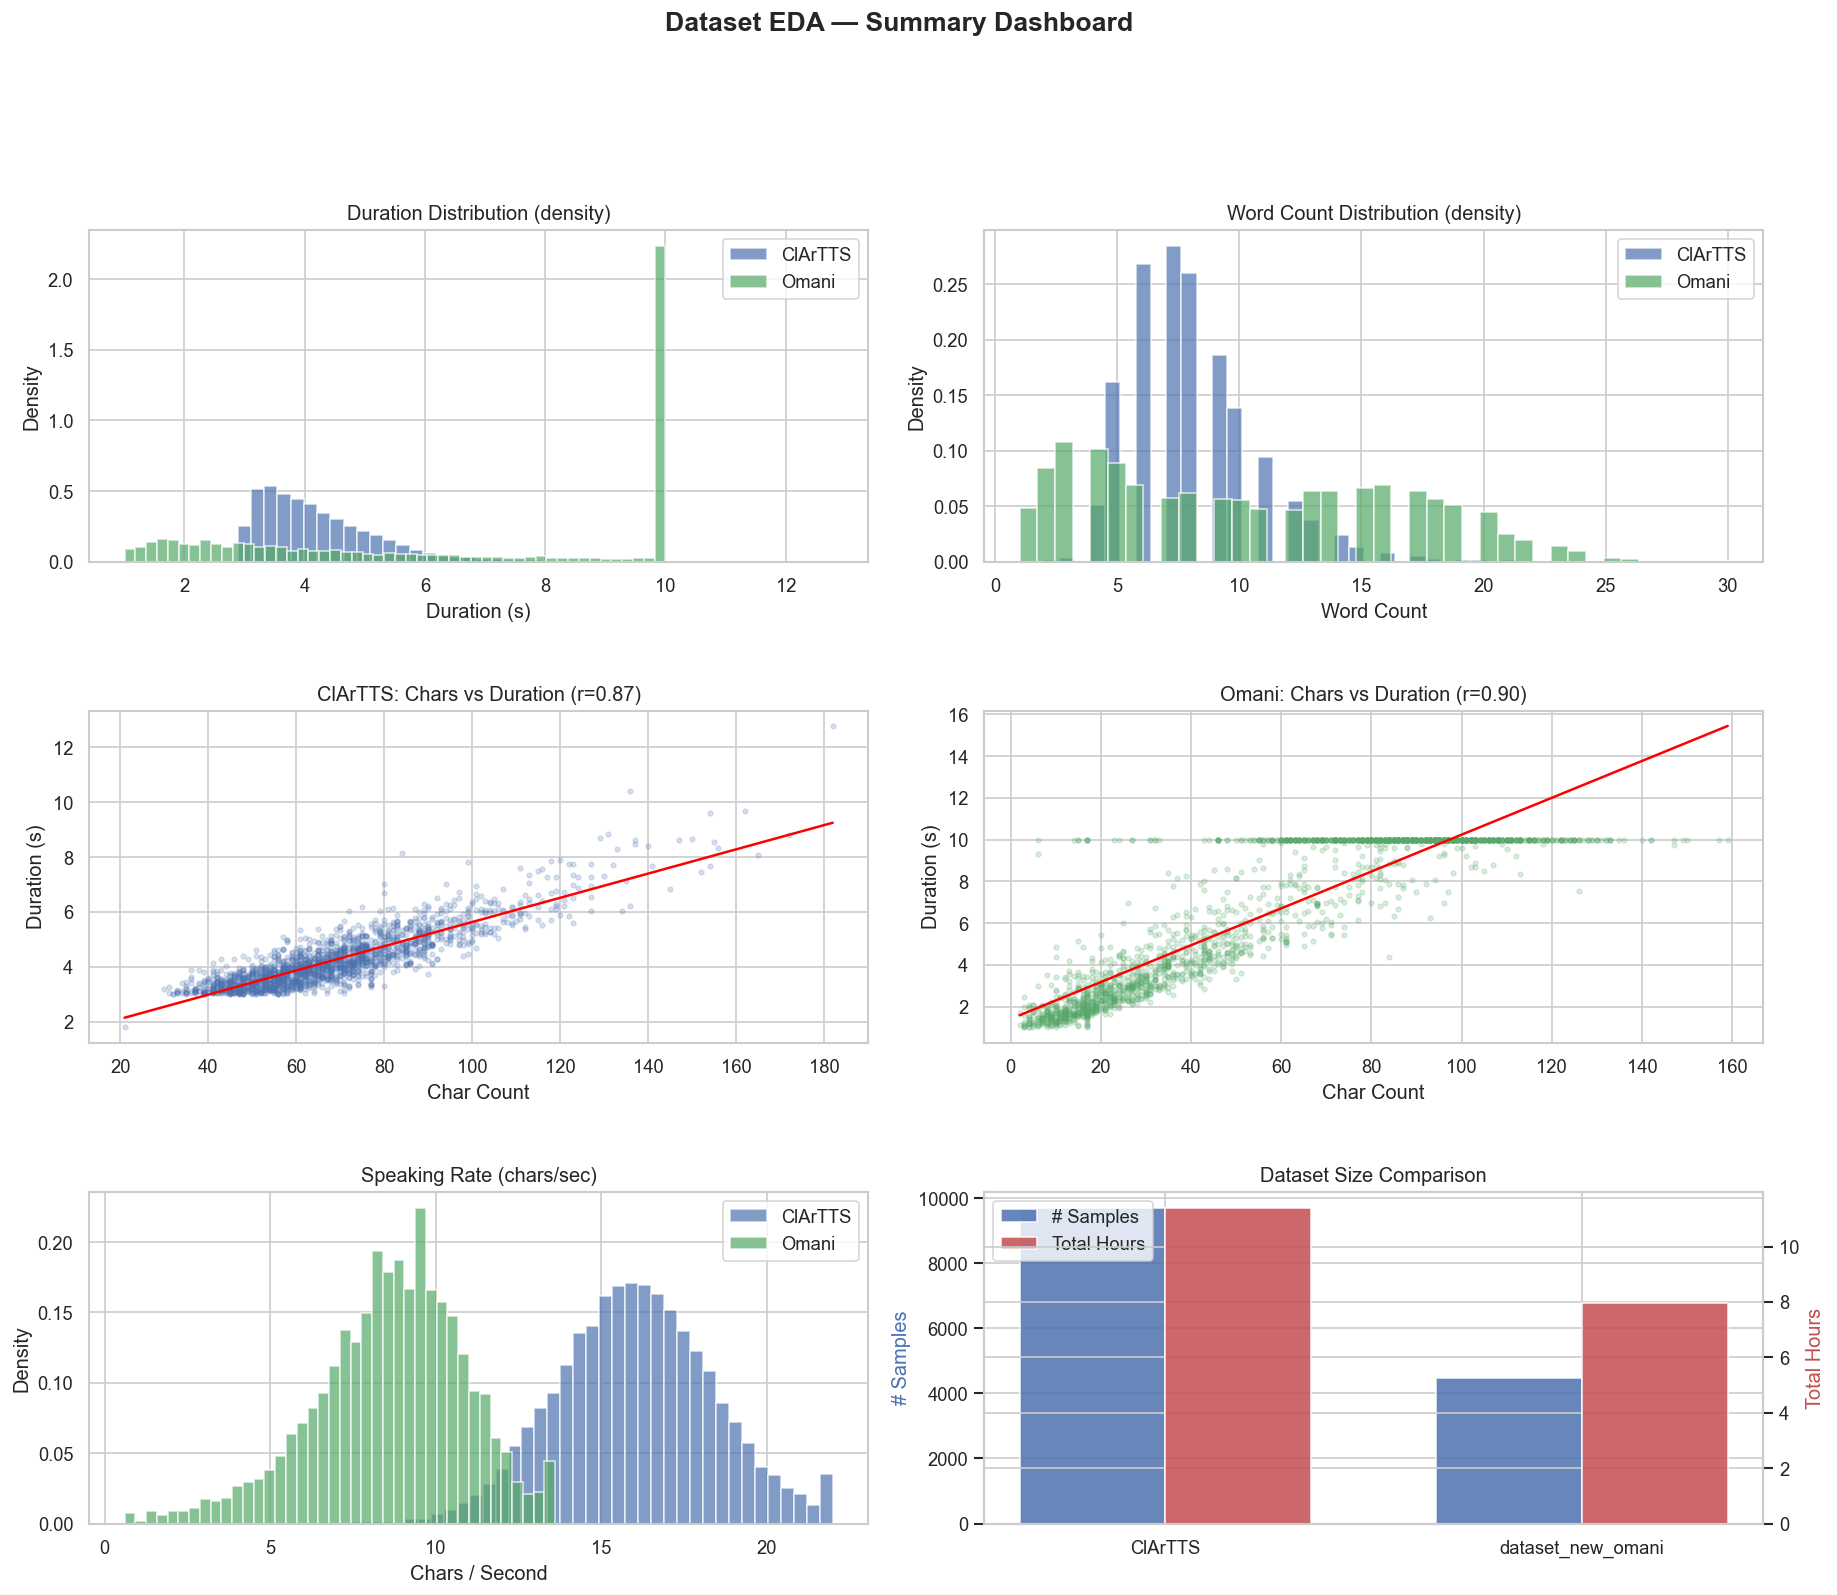

All plots saved.


In [24]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dataset EDA — Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# Row 0: Duration histograms
ax0 = fig.add_subplot(gs[0, :2])
ax0.hist(clartts['duration'], bins=50, color='#4C72B0', alpha=0.7, label='ClArTTS', density=True)
ax0.hist(omani['duration'],   bins=50, color='#55A868', alpha=0.7, label='Omani',   density=True)
ax0.set_title('Duration Distribution (density)')
ax0.set_xlabel('Duration (s)'); ax0.set_ylabel('Density')
ax0.legend()

# Row 0: Word count distributions
ax1 = fig.add_subplot(gs[0, 2:])
ax1.hist(clartts['word_count'], bins=40, color='#4C72B0', alpha=0.7, label='ClArTTS', density=True)
ax1.hist(omani['word_count'],   bins=40, color='#55A868', alpha=0.7, label='Omani',   density=True)
ax1.set_title('Word Count Distribution (density)')
ax1.set_xlabel('Word Count'); ax1.set_ylabel('Density')
ax1.legend()

# Row 1: Scatter — ClArTTS
ax2 = fig.add_subplot(gs[1, :2])
s = clartts.sample(2000, random_state=42)
ax2.scatter(s['char_count'], s['duration'], alpha=0.2, s=8, color='#4C72B0')
z = np.polyfit(s['char_count'], s['duration'], 1)
xs = np.linspace(s['char_count'].min(), s['char_count'].max(), 200)
ax2.plot(xs, np.poly1d(z)(xs), color='red', lw=1.5)
ax2.set_title(f'ClArTTS: Chars vs Duration (r={clartts["char_count"].corr(clartts["duration"]):.2f})')
ax2.set_xlabel('Char Count'); ax2.set_ylabel('Duration (s)')

# Row 1: Scatter — Omani
ax3 = fig.add_subplot(gs[1, 2:])
s = omani.sample(min(2000, len(omani)), random_state=42)
ax3.scatter(s['char_count'], s['duration'], alpha=0.2, s=8, color='#55A868')
z = np.polyfit(s['char_count'], s['duration'], 1)
xs = np.linspace(s['char_count'].min(), s['char_count'].max(), 200)
ax3.plot(xs, np.poly1d(z)(xs), color='red', lw=1.5)
ax3.set_title(f'Omani: Chars vs Duration (r={omani["char_count"].corr(omani["duration"]):.2f})')
ax3.set_xlabel('Char Count'); ax3.set_ylabel('Duration (s)')

# Row 2: Speaking rate
ax4 = fig.add_subplot(gs[2, :2])
ax4.hist(clartts['chars_per_sec'].clip(0, clartts['chars_per_sec'].quantile(0.99)),
         bins=40, color='#4C72B0', alpha=0.7, label='ClArTTS', density=True)
ax4.hist(omani['chars_per_sec'].clip(0, omani['chars_per_sec'].quantile(0.99)),
         bins=40, color='#55A868', alpha=0.7, label='Omani',   density=True)
ax4.set_title('Speaking Rate (chars/sec)')
ax4.set_xlabel('Chars / Second'); ax4.set_ylabel('Density')
ax4.legend()

# Row 2: Dataset size comparison bar
ax5 = fig.add_subplot(gs[2, 2:])
datasets   = ['ClArTTS', 'dataset_new_omani']
n_samples  = [len(clartts), len(omani)]
total_hrs  = [clartts['duration'].sum()/3600, omani['duration'].sum()/3600]
x = np.arange(2)
width = 0.35
b1 = ax5.bar(x - width/2, n_samples, width, label='# Samples', color='#4C72B0', alpha=0.85)
ax5_r = ax5.twinx()
b2 = ax5_r.bar(x + width/2, total_hrs, width, label='Total Hours', color='#C44E52', alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels(datasets)
ax5.set_ylabel('# Samples', color='#4C72B0')
ax5_r.set_ylabel('Total Hours', color='#C44E52')
ax5.set_title('Dataset Size Comparison')
lines = [b1, b2]
labels_leg = ['# Samples', 'Total Hours']
ax5.legend(lines, labels_leg, loc='upper left')

plt.savefig('eda_summary_dashboard.png', bbox_inches='tight')
plt.show()
print('All plots saved.')

## 5. Summary Table

In [25]:
summary = pd.DataFrame({
    'Metric': [
        'Total Samples', 'Total Duration (h)', 'Mean Duration (s)', 'Median Duration (s)',
        'Std Duration (s)', 'Min Duration (s)', 'Max Duration (s)',
        'Mean Char Count', 'Mean Word Count', 'Mean Chars/Sec (speaking rate)',
        'Language', 'Speakers', 'Audio Format'
    ],
    'ClArTTS': [
        f"{len(clartts):,}",
        f"{clartts['duration'].sum()/3600:.2f}",
        f"{clartts['duration'].mean():.2f}",
        f"{clartts['duration'].median():.2f}",
        f"{clartts['duration'].std():.2f}",
        f"{clartts['duration'].min():.2f}",
        f"{clartts['duration'].max():.2f}",
        f"{clartts['char_count'].mean():.1f}",
        f"{clartts['word_count'].mean():.1f}",
        f"{clartts['chars_per_sec'].median():.1f}",
        'Modern Standard Arabic (MSA)',
        'Single speaker',
        'Parquet (float32 PCM, 40.1 kHz resampled)'
    ],
    'dataset_new_omani': [
        f"{len(omani):,}",
        f"{omani['duration'].sum()/3600:.2f}",
        f"{omani['duration'].mean():.2f}",
        f"{omani['duration'].median():.2f}",
        f"{omani['duration'].std():.2f}",
        f"{omani['duration'].min():.2f}",
        f"{omani['duration'].max():.2f}",
        f"{omani['char_count'].mean():.1f}",
        f"{omani['word_count'].mean():.1f}",
        f"{omani['chars_per_sec'].median():.1f}",
        'Omani Arabic (dialect)',
        'Single speaker',
        'FLAC'
    ]
})

summary.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f0f0f0')]}]
)

,Metric,ClArTTS,dataset_new_omani
0,Total Samples,"9,705","4,478"
1,Total Duration (h),11.40,7.96
2,Mean Duration (s),4.23,6.40
3,Median Duration (s),4.01,6.43
4,Std Duration (s),1.00,3.42
5,Min Duration (s),1.79,1.01
6,Max Duration (s),12.78,10.00
7,Mean Char Count,68.3,56.6
8,Mean Word Count,8.0,10.4
9,Mean Chars/Sec (speaking rate),16.0,8.8
